# Lichess Chess Game Data Mining Pipeline

**Dataset:** Lichess Standard Rated Games — February 2026  
**Format:** PGN (Portable Game Notation), compressed as `.pgn.zst`  
**Goal:** Parse, clean, engineer features, and analyze chess game outcomes using descriptive statistics, frequent-pattern mining, association rules, and supervised classification.

---

## Pipeline Overview

| Section | Task |
|---|---|
| 1 | Data ingestion and PGN parsing |
| 2 | Data cleaning and standardization |
| 3 | Feature engineering |
| 4 | Descriptive analysis |
| 5 | Frequent patterns and association rules |
| 6 | Supervised classification |

The pipeline is designed to be first validated on a **small sample** (`SAMPLE_MODE = True`), then scaled to the full 184 GB dataset by setting `SAMPLE_MODE = False`.

---
## Chess Terminology Primer

If you don't play chess, here are the terms and abbreviations used throughout this notebook.

**Notation formats**
- **PGN (Portable Game Notation)** — the plain-text file format the raw dataset comes in. Each game is a block of header tags (`[WhiteElo "1696"]`, etc.) followed by the list of moves.
- **SAN (Standard Algebraic Notation)** — how individual moves are written, e.g. `e4`, `Nf3`, `O-O`. This is what ends up in the `ply_1` … `ply_6` columns.
  - Piece letters: `K` king, `Q` queen, `R` rook, `B` bishop, `N` knight. A move with no letter (e.g. `e4`, `d5`) is a pawn move.
  - `x` = capture (e.g. `Nxd5`), `+` = check, `#` = checkmate.
  - `O-O` = castling kingside, `O-O-O` = castling queenside.

**Moves**
- **Ply / half-move** — one move by one player. A "full move" is White's move plus Black's reply; a ply is just one side's move. `ply_1` is White's first move, `ply_2` is Black's first reply, and so on. This notebook only keeps the first `K_MOVES` plies (the opening) of each game.

**Ratings and outcome**
- **Elo rating** (`white_elo`, `black_elo`) — a numeric skill rating; higher means a stronger player. `rating_diff` is White's rating minus Black's.
- **Result** — recorded as `1-0` (White won), `0-1` (Black won), or `1/2-1/2` (draw); the notebook relabels these as `white_win`, `black_win`, `draw`.
- **Termination** — how the game ended: `Normal` (checkmate/resignation), `Time forfeit` (a player ran out of the clock), or `Abandoned`.

**Time control**
- **Time control** (e.g. `60+0`) — written as `base+increment` in seconds: starting clock time, plus seconds added per move. `60+0` means 60 seconds total with no increment.
- Derived category (`tc_cat`) based on estimated total game time: **Bullet** (< 3 min), **Blitz** (3–10 min), **Rapid** (10+ min), **Classical** (slower, longer games).

**Openings**
- **Opening** — the named sequence of early moves a game follows (e.g. "Caro-Kann Defense: Advance Variation"), analogous to a recognized playbook of first moves.
- **ECO code** — a short code (e.g. `B12`) from the *Encyclopaedia of Chess Openings* classifying the opening. The first letter (`eco_family`, A–E) groups openings into broad families: A = flank openings, B = semi-open games, C = open games, D = closed games, E = Indian defenses.

---
## Section 0: Setup and Configuration

In [1]:
# Install packages not in the base environment
# python-chess: PGN parsing   mlxtend: frequent pattern and association rule mining
%pip install python-chess mlxtend -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
## Install all packages in requirements.txt
%pip install -r requirements.txt -q

## Import necessary libraries
import os
import re
import time
import warnings

# Data manipulation and visualization
import chess.pgn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# Association rule mining libraries
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Suppress warnings and set visualization theme
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Check if all imports were successful
print('All imports successful.')

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


Note: you may need to restart the kernel to use updated packages.
All imports successful.


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = os.path.abspath('..')   # notebooks/ -> project root
RAW_PGN    = os.path.join(BASE_DIR, 'data', 'raw',       'lichess_db_standard_rated_2026-02.pgn')
INTERIM    = os.path.join(BASE_DIR, 'data', 'interim')
PROCESSED  = os.path.join(BASE_DIR, 'data', 'processed')

# ── Pipeline parameters ────────────────────────────────────────────────────
SAMPLE_MODE = True      # Set False to run on full dataset
N_SAMPLE    = 50_000    # Games to parse in sample mode
RANDOM_SEED = 42        # Random seed for reproducibility
K_MOVES     = 6         # Half-moves (plies) to extract per game

# ── Validate paths ─────────────────────────────────────────────────────────
assert os.path.exists(RAW_PGN),   f'PGN not found: {RAW_PGN}'
assert os.path.isdir(INTERIM),    f'Interim dir missing: {INTERIM}'
assert os.path.isdir(PROCESSED),  f'Processed dir missing: {PROCESSED}'

pgn_gb = os.path.getsize(RAW_PGN) / 1e9
print(f'PGN file:    {RAW_PGN}')
print(f'PGN size:    {pgn_gb:.1f} GB')
print(f'Sample mode: {SAMPLE_MODE}  (N = {N_SAMPLE if SAMPLE_MODE else "ALL"})')
print(f'Plies/game:  {K_MOVES}')

PGN file:    c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\raw\lichess_db_standard_rated_2026-02.pgn
PGN size:    197.7 GB
Sample mode: True  (N = 50000)
Plies/game:  6


---
## Section 1: Data Ingestion and PGN Parsing

### 1.1 PGN Format

PGN (Portable Game Notation) is a plain-text chess game format. Each game consists of a **header block** of bracketed tag-value pairs followed by a **movetext** block. Example:

```
[Event "Rated Bullet game"]
[WhiteElo "1696"]
[BlackElo "1617"]
[ECO "B12"]
[Opening "Caro-Kann Defense: Advance Variation"]
[TimeControl "60+0"]
[Result "1-0"]
[Termination "Time forfeit"]

1. e4 { [%clk 0:01:00] } 1... c6 { [%clk 0:01:00] } 2. d4 ...
```

The `python-chess` library handles PGN parsing, converting movetext into Standard Algebraic Notation (SAN) moves (e.g., `e4`, `Nf3`, `O-O`).

### 1.2 Parsing Strategy

Games are parsed **sequentially** from the file — loading the full 184 GB into memory is not feasible. In `SAMPLE_MODE`, we stop after `N_SAMPLE` games. The full-dataset run simply removes that stopping condition.

For each game, the following are extracted:
- All header metadata (ratings, ECO, opening, time control, result, termination)
- Total ply count (full walk of mainline moves)
- First `K_MOVES` half-moves in SAN format

In [4]:
def classify_time_control(tc):
    """
    Map a Lichess time-control string ('base+increment') to a category.

    Lichess records dozens of distinct base+increment combinations
    (e.g. '60+0', '180+2', '600+0'), which is too granular to group on
    directly. Bucketing into bullet/blitz/rapid/classical gives later
    sections (outcome rates, ratings, openings) a small set of
    meaningful categories to compare instead.
    """
    # PGN's TimeControl header is '?' or '-' when no clock was used (e.g. correspondence).
    if not tc or tc in ('?', '-'):
        return 'unknown'
    try:
        # TimeControl is 'base+increment' in seconds (e.g. '180+2' = 3 min + 2s/move).
        # A bare number with no '+' means zero increment.
        if '+' in tc:
            base_s, incr_s = (int(x) for x in tc.split('+', 1))
        else:
            base_s, incr_s = int(tc), 0
        # Estimated total time: base + 40 moves * increment (FIDE convention).
        # Increment adds up over the course of a game, so raw base time alone
        # would misclassify, e.g., a slow-increment game as faster than it plays.
        estimated = base_s + 40 * incr_s
        # Thresholds mirror Lichess's own bullet/blitz/rapid/classical cutoffs.
        if estimated < 180:
            return 'bullet'
        elif estimated < 600:
            return 'blitz'
        elif estimated < 1800:
            return 'rapid'
        return 'classical'
    except Exception:
        # Guards against malformed/unexpected TimeControl strings so one bad
        # row doesn't crash parsing of the whole batch.
        return 'other'

In [5]:
def parse_pgn(pgn_path, n_games=None, k_moves=6):
    """
    Stream-parse a PGN file into a DataFrame.

    Parameters
    ----------
    pgn_path : str   Path to the (already decompressed) PGN file.
    n_games  : int   Stop after this many games (None = parse all).
    k_moves  : int   Number of half-moves (plies) to extract per game.

    Returns
    -------
    pd.DataFrame  One row per game.
    """
    records = []
    t0 = time.time()

    with open(pgn_path, encoding='utf-8', errors='replace') as pgn:
        idx = 0
        while (n_games is None) or (idx < n_games):
            game = chess.pgn.read_game(pgn)
            if game is None:
                break

            h = game.headers

            # Walk the mainline to count total plies and extract first k_moves
            board = game.board()
            all_moves = list(game.mainline_moves())
            num_plies = len(all_moves)

            plies = []
            for mv in all_moves[:k_moves]:
                plies.append(board.san(mv))
                board.push(mv)

            rec = {
                'game_id':           idx,
                'event':             h.get('Event',           '?'),
                'result':            h.get('Result',          '?'),
                'utc_date':          h.get('UTCDate',         '?'),
                'white_elo':         h.get('WhiteElo',        '?'),
                'black_elo':         h.get('BlackElo',        '?'),
                'white_rating_diff': h.get('WhiteRatingDiff', '?'),
                'black_rating_diff': h.get('BlackRatingDiff', '?'),
                'eco':               h.get('ECO',             '?'),
                'opening':           h.get('Opening',         '?'),
                'time_control':      h.get('TimeControl',     '?'),
                'termination':       h.get('Termination',     '?'),
                'num_plies':         num_plies,
            }

            for i, ply in enumerate(plies):
                rec[f'ply_{i + 1}'] = ply
            for i in range(len(plies), k_moves):
                rec[f'ply_{i + 1}'] = None

            records.append(rec)
            idx += 1

            if idx % 10_000 == 0:
                elapsed = time.time() - t0
                print(f'  {idx:>10,}  |  {elapsed:.0f}s  |  {idx / elapsed:,.0f} games/s')

    elapsed = time.time() - t0
    print(f'Done: {idx:,} games in {elapsed:.1f}s  ({idx / elapsed:,.0f} games/s)')
    return pd.DataFrame(records)

In [6]:
n_to_parse = N_SAMPLE if SAMPLE_MODE else None
label = f'first {n_to_parse:,}' if n_to_parse else 'ALL'
print(f'Parsing {label} games from PGN ...\n')

df_raw = parse_pgn(RAW_PGN, n_games=n_to_parse, k_moves=K_MOVES)

print(f'\nRaw DataFrame shape: {df_raw.shape}')

Parsing first 50,000 games from PGN ...

      10,000  |  23s  |  438 games/s
      20,000  |  46s  |  438 games/s
      30,000  |  69s  |  435 games/s
      40,000  |  93s  |  429 games/s
      50,000  |  118s  |  424 games/s
Done: 50,000 games in 118.0s  (424 games/s)

Raw DataFrame shape: (50000, 19)


In [7]:
print('Column overview:')
print(df_raw.dtypes)
print()
df_raw.head(3)

Column overview:
game_id              int64
event                  str
result                 str
utc_date               str
white_elo              str
black_elo              str
white_rating_diff      str
black_rating_diff      str
eco                    str
opening                str
time_control           str
termination            str
num_plies            int64
ply_1                  str
ply_2                  str
ply_3                  str
ply_4                  str
ply_5                  str
ply_6                  str
dtype: object



,game_id,event,result,utc_date,white_elo,black_elo,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,ply_1,ply_2,ply_3,ply_4,ply_5,ply_6
0,0,Rated Bullet game,1-0,2026.02.01,1696,1617,+4,-4,B12,"Caro-Kann Defense: Advance Variation, Short Va...",60+0,Time forfeit,75,e4,c6,d4,d5,e5,Bf5
1,1,Rated Bullet game,1-0,2026.02.01,2193,2228,+6,-6,D46,Semi-Slav Defense: Romih Variation,60+0,Time forfeit,61,d4,Nf6,Nf3,d5,c4,e6
2,2,Rated Bullet tournament https://lichess.org/to...,1-0,2026.02.01,2327,2335,+6,-6,A15,"English Opening: Anglo-Indian Defense, Scandin...",60+0,Normal,23,Nf3,d5,c4,Nf6,cxd5,Nxd5


In [8]:
raw_path = os.path.join(INTERIM, 'games_raw.parquet')
df_raw.to_parquet(raw_path, index=False)
size_mb = os.path.getsize(raw_path) / 1e6
print(f'Saved: {raw_path}  ({size_mb:.1f} MB)')

Saved: c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\interim\games_raw.parquet  (1.1 MB)


---
### Section 1 Recap

**What was done:** Streamed 50,000 sample games out of the 197.7 GB Lichess PGN file one game at a time (so memory use doesn't scale with file size), pulling out header metadata (ratings, ECO, opening, time control, result, termination), the total ply count, and the first `K_MOVES` (6) half-moves in SAN. Saved the result to `games_raw.parquet`.

**Trends worth noting:**
- All three preview rows came back as `Rated Bullet` games on a `60+0` clock -- an early hint, confirmed later in Section 3/4, that this sample skews heavily toward fast time controls.
- Two of the three preview games ended in `Time forfeit` rather than checkmate/resignation -- unsurprising at a 60-second time control, where the clock is often the real opponent.

---
## Section 2: Data Cleaning

### Cleaning Steps

| Step | Action |
|---|---|
| Type conversion | Parse `white_elo` / `black_elo` to integers; coerce invalid strings to `NaN` |
| Missing metadata | Drop games missing ratings, result, or time control |
| Invalid results | Keep only `1-0`, `0-1`, `1/2-1/2`; drop `*` and malformed values |
| Implausible ratings | Remove Elo values outside 100–3500 |
| Minimal game length | Remove games with fewer than 2 plies (abandoned immediately) |
| Result standardization | Map `1-0` → `white_win`, `0-1` → `black_win`, `1/2-1/2` → `draw` |

In [9]:
print('Missing values in key columns (before cleaning):')
key_cols = ['white_elo', 'black_elo', 'eco', 'opening', 'time_control', 'termination']
missing_before = df_raw[key_cols].replace('?', np.nan).isna().sum()
for col, n in missing_before.items():
    pct = n / len(df_raw) * 100
    print(f'  {col:<16}  {n:>6,}  ({pct:.1f}%)')

Missing values in key columns (before cleaning):
  white_elo              0  (0.0%)
  black_elo              0  (0.0%)
  eco                   80  (0.2%)
  opening               80  (0.2%)
  time_control           0  (0.0%)
  termination            0  (0.0%)


In [10]:
df = df_raw.copy()

# ── Numeric conversion ─────────────────────────────────────────────────────
def to_int_or_nan(s):
    try:
        return int(s)
    except (ValueError, TypeError):
        return np.nan

df['white_elo'] = df['white_elo'].apply(to_int_or_nan)
df['black_elo'] = df['black_elo'].apply(to_int_or_nan)

# ── Quality flags ──────────────────────────────────────────────────────────
VALID_RESULTS = {'1-0', '0-1', '1/2-1/2'}

mask_bad = (
    ~df['result'].isin(VALID_RESULTS)
    | df['white_elo'].isna()
    | df['black_elo'].isna()
    | (df['num_plies'] < 2)
    | (df['white_elo'] < 100) | (df['white_elo'] > 3500)
    | (df['black_elo'] < 100) | (df['black_elo'] > 3500)
)

n_before = len(df)
df_clean = df[~mask_bad].copy()
n_after  = len(df_clean)

print(f'Games before cleaning: {n_before:,}')
print(f'Games removed:         {n_before - n_after:,}  ({(n_before - n_after) / n_before * 100:.2f}%)')
print(f'Games after cleaning:  {n_after:,}')

Games before cleaning: 50,000
Games removed:         164  (0.33%)
Games after cleaning:  49,836


In [11]:
# ── Standardize result labels ──────────────────────────────────────────────
result_map = {'1-0': 'white_win', '0-1': 'black_win', '1/2-1/2': 'draw'}
df_clean['result_label'] = df_clean['result'].map(result_map)

# ── Elo to integer ─────────────────────────────────────────────────────────
df_clean['white_elo'] = df_clean['white_elo'].astype(int)
df_clean['black_elo'] = df_clean['black_elo'].astype(int)

print('Outcome distribution after standardization:')
vc = df_clean['result_label'].value_counts()
for label, count in vc.items():
    print(f'  {label:<12}  {count:>8,}  ({count / len(df_clean) * 100:.1f}%)')

Outcome distribution after standardization:
  white_win       24,837  (49.8%)
  black_win       23,147  (46.4%)
  draw             1,852  (3.7%)


In [12]:
print('Missing values in key columns (after cleaning):')
key_cols = ['white_elo', 'black_elo', 'eco', 'opening', 'time_control', 'termination']
missing = df_clean[key_cols].replace('?', np.nan).isna().sum()
for col, n in missing.items():
    pct = n / len(df_clean) * 100
    print(f'  {col:<16}  {n:>6,}  ({pct:.1f}%)')

Missing values in key columns (after cleaning):
  white_elo              0  (0.0%)
  black_elo              0  (0.0%)
  eco                    0  (0.0%)
  opening                0  (0.0%)
  time_control           0  (0.0%)
  termination            0  (0.0%)


In [13]:
clean_path = os.path.join(INTERIM, 'games_cleaned.parquet')
df_clean.to_parquet(clean_path, index=False)
print(f'Saved cleaned data: {clean_path}  (shape: {df_clean.shape})')

Saved cleaned data: c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\interim\games_cleaned.parquet  (shape: (49836, 20))


---
### Section 2 Recap

**What was done:** Converted `white_elo`/`black_elo` to numeric, then dropped games with an invalid result, missing/implausible ratings (outside 100-3500), or fewer than 2 plies (abandoned immediately). 164 games (0.33%) were removed, leaving 49,836. Result strings were standardized from `1-0`/`0-1`/`1/2-1/2` into `white_win`/`black_win`/`draw` labels, and the cleaned table was saved to `games_cleaned.parquet`.

**Trends worth noting:**
- Only 0.33% of games were dropped -- Lichess's PGN export is already quite well-formed, so cleaning here is mostly a safety net rather than a major filtering step.
- The standardized outcome counts already show a clear pattern: `white_win` 49.8%, `black_win` 46.4%, `draw` only 3.7%. The ~3.4-point White edge lines up with chess theory's well-known first-move advantage, and the low draw rate is typical of fast online play rather than classical over-the-board chess, where draws are far more common.

---
## Section 3: Feature Engineering

### Derived Variables

| Feature | Description |
|---|---|
| `rating_diff` | `white_elo - black_elo`; positive means White is stronger |
| `avg_rating` | `(white_elo + black_elo) / 2`; proxy for game quality level |
| `rating_bin` | Discretized `avg_rating`: `<1000`, `1000-1499`, `1500-1999`, `2000+` |
| `num_moves` | Full moves = `num_plies // 2` |
| `tc_cat` | Bullet / Blitz / Rapid / Classical derived from `time_control` |
| `eco_family` | First letter of ECO code (A–E), broad opening family |
| `opening_family` | Text before the first `:` in the Opening tag |
| `white_wins` | Binary outcome: 1 if White wins, 0 otherwise |
| `higher_rated_wins` | Binary: 1 if the higher-rated player won (draws and equal-rating games → NaN) |

The first `K_MOVES` ply columns (`ply_1` … `ply_6`) from parsing are carried through for the association-rule and classification analyses.

In [14]:
df_feat = df_clean.copy()

# ── Rating features ────────────────────────────────────────────────────────
df_feat['rating_diff'] = df_feat['white_elo'] - df_feat['black_elo']
df_feat['avg_rating']  = (df_feat['white_elo'] + df_feat['black_elo']) / 2

rating_bins   = [0, 999, 1499, 1999, np.inf]
rating_labels = ['<1000', '1000-1499', '1500-1999', '2000+']
df_feat['rating_bin'] = pd.cut(
    df_feat['avg_rating'],
    bins=rating_bins,
    labels=rating_labels
).astype(str)

print('Rating bin counts:')
print(df_feat['rating_bin'].value_counts().sort_index())

Rating bin counts:
rating_bin
1000-1499    14246
1500-1999    22815
2000+         9908
<1000         2867
Name: count, dtype: int64


In [15]:
# ── Game-length features ───────────────────────────────────────────────────
df_feat['num_moves'] = df_feat['num_plies'] // 2

# ── Time-control category ──────────────────────────────────────────────────
df_feat['tc_cat'] = df_feat['time_control'].apply(classify_time_control)

print('Time control category counts:')
print(df_feat['tc_cat'].value_counts())

Time control category counts:
tc_cat
blitz        23421
bullet       18922
rapid         7282
classical      174
unknown         37
Name: count, dtype: int64


In [16]:
# ── Opening features ───────────────────────────────────────────────────────
# ECO family: first letter (A=flank, B=semi-open, C=open, D=closed, E=Indian)
df_feat['eco_family'] = df_feat['eco'].where(
    df_feat['eco'].str.len() >= 1, np.nan
).str[0]
df_feat.loc[df_feat['eco_family'] == '?', 'eco_family'] = np.nan

# Opening family: text before the first colon in the Opening tag
df_feat['opening_family'] = (
    df_feat['opening']
    .str.split(':').str[0]
    .str.strip()
    .replace({'?': np.nan, '': np.nan})
)

print('ECO family distribution:')
print(df_feat['eco_family'].value_counts())
print(f'\nDistinct opening families: {df_feat["opening_family"].nunique()}')

ECO family distribution:
eco_family
B    15181
C    14028
A    13447
D     6524
E      656
Name: count, dtype: int64

Distinct opening families: 131


In [17]:
# ── Binary outcome: White wins ─────────────────────────────────────────────
df_feat['white_wins'] = (df_feat['result_label'] == 'white_win').astype(int)

# ── Binary outcome: higher-rated player wins ───────────────────────────────
def higher_rated_wins(row):
    rd = row['rating_diff']
    res = row['result_label']
    if rd > 0:    # White is higher rated
        return 1 if res == 'white_win' else (0 if res == 'black_win' else np.nan)
    elif rd < 0:  # Black is higher rated
        return 1 if res == 'black_win'  else (0 if res == 'white_win' else np.nan)
    return np.nan  # Equal rating

df_feat['higher_rated_wins'] = df_feat.apply(higher_rated_wins, axis=1)

print('higher_rated_wins distribution (NaN = draw or equal ratings):')
print(df_feat['higher_rated_wins'].value_counts(dropna=False))

higher_rated_wins distribution (NaN = draw or equal ratings):
higher_rated_wins
1.0    26220
0.0    21100
NaN     2516
Name: count, dtype: int64


In [18]:
# ── Save main game-level features table ───────────────────────────────────
feat_path = os.path.join(PROCESSED, 'games_featured.parquet')
df_feat.to_parquet(feat_path, index=False)

# ── Save move-sequence table ───────────────────────────────────────────────
ply_cols   = [f'ply_{i + 1}' for i in range(K_MOVES)]
move_cols  = ['game_id'] + ply_cols + ['result_label', 'num_plies', 'num_moves']
df_moves   = df_feat[move_cols].copy()
moves_path = os.path.join(PROCESSED, 'move_sequences.parquet')
df_moves.to_parquet(moves_path, index=False)

print(f'Saved game features:   {feat_path}  ({df_feat.shape})')
print(f'Saved move sequences:  {moves_path}  ({df_moves.shape})')
print(f'\nFinal feature columns:')
print(df_feat.columns.tolist())

Saved game features:   c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\processed\games_featured.parquet  ((49836, 29))
Saved move sequences:  c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\processed\move_sequences.parquet  ((49836, 10))

Final feature columns:
['game_id', 'event', 'result', 'utc_date', 'white_elo', 'black_elo', 'white_rating_diff', 'black_rating_diff', 'eco', 'opening', 'time_control', 'termination', 'num_plies', 'ply_1', 'ply_2', 'ply_3', 'ply_4', 'ply_5', 'ply_6', 'result_label', 'rating_diff', 'avg_rating', 'rating_bin', 'num_moves', 'tc_cat', 'eco_family', 'opening_family', 'white_wins', 'higher_rated_wins']


---
### Section 3 Recap

**What was done:** Engineered `rating_diff`, `avg_rating`, a 4-tier `rating_bin`, `num_moves`, a `tc_cat` bucket (bullet/blitz/rapid/classical), `eco_family` (first ECO letter), `opening_family` (131 distinct families), and the two prediction targets `white_wins` and `higher_rated_wins`. Saved the enriched table to `games_featured.parquet` and a separate `ply_1`...`ply_6` move-sequence table to `move_sequences.parquet`.

**Trends worth noting:**
- `rating_bin` is bell-shaped and centered on `1500-1999` (22,815 games, 45.8%), with far fewer games at the tails (`<1000`: 5.8%, `2000+`: 19.9%) -- a fairly typical skill distribution for an open rated pool.
- `tc_cat` confirms the bullet/blitz skew hinted at in Section 1: blitz (23,421) and bullet (18,922) together make up roughly 85% of the sample, rapid is a distant third (7,282), and classical is nearly absent (174).
- `higher_rated_wins` shows the higher-rated player wins about 55.4% of decisive games (26,220 of 47,320) -- a real but modest skill signal, and a preview of Section 6's finding that rating difference ends up the single most predictive feature.

---
## Section 4: Descriptive Analysis

This section summarizes the dataset and compares outcome rates across key groupings using counts, percentages, means, medians, standard deviations, and interquartile ranges. Chi-squared tests on contingency tables assess whether observed differences across groups are statistically noteworthy.

### 4.1 Dataset Overview

In [19]:
print('=== Dataset Overview ===')
print(f'Total games:     {len(df_feat):,}')
print(f'Date range:      {df_feat["utc_date"].min()} to {df_feat["utc_date"].max()}')
print()

num_summary_cols = ['white_elo', 'black_elo', 'rating_diff', 'avg_rating', 'num_plies', 'num_moves']
summary = df_feat[num_summary_cols].agg(['count', 'mean', 'median', 'std',
                                         lambda x: x.quantile(0.25),
                                         lambda x: x.quantile(0.75)]).T
summary.columns = ['n', 'mean', 'median', 'std', 'Q1', 'Q3']
summary['IQR'] = summary['Q3'] - summary['Q1']
print(summary.round(1).to_string())

=== Dataset Overview ===
Total games:     49,836
Date range:      2026.02.01 to 2026.02.01

                   n    mean  median    std      Q1      Q3    IQR
white_elo    49836.0  1656.8  1672.0  404.0  1378.0  1941.0  563.0
black_elo    49836.0  1656.9  1673.0  404.3  1380.0  1941.0  561.0
rating_diff  49836.0    -0.0     0.0  120.6   -32.0    33.0   65.0
avg_rating   49836.0  1656.8  1673.5  399.7  1383.5  1938.5  555.0
num_plies    49836.0    67.1    63.0   30.7    46.0    85.0   39.0
num_moves    49836.0    33.3    31.0   15.4    23.0    42.0   19.0


### 4.2 Rating Distributions

Understanding the rating landscape helps contextualize outcome patterns. A symmetric rating-difference distribution centered at zero confirms that Lichess does not systematically pair players of dramatically different skill.

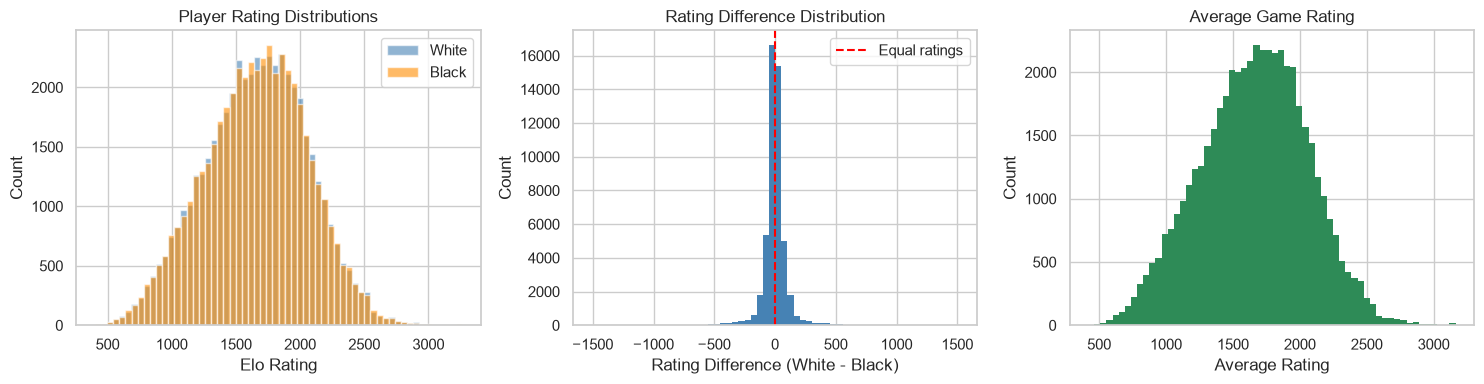

Rating bin counts and percentages:
  1000-1499       14,246  (28.6%)
  1500-1999       22,815  (45.8%)
  2000+            9,908  (19.9%)
  <1000            2,867  (5.8%)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_feat['white_elo'], bins=60, alpha=0.6, label='White', color='steelblue')
axes[0].hist(df_feat['black_elo'], bins=60, alpha=0.6, label='Black', color='darkorange')
axes[0].set_xlabel('Elo Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Player Rating Distributions')
axes[0].legend()

axes[1].hist(df_feat['rating_diff'], bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal ratings')
axes[1].set_xlabel('Rating Difference (White - Black)')
axes[1].set_ylabel('Count')
axes[1].set_title('Rating Difference Distribution')
axes[1].legend()

axes[2].hist(df_feat['avg_rating'], bins=60, color='seagreen', edgecolor='none')
axes[2].set_xlabel('Average Rating')
axes[2].set_ylabel('Count')
axes[2].set_title('Average Game Rating')

plt.tight_layout()
plt.show()

print('Rating bin counts and percentages:')
rb = df_feat['rating_bin'].value_counts().sort_index()
for bin_label, cnt in rb.items():
    print(f'  {bin_label:<12}  {cnt:>8,}  ({cnt / len(df_feat) * 100:.1f}%)')

### 4.3 Outcome Distributions

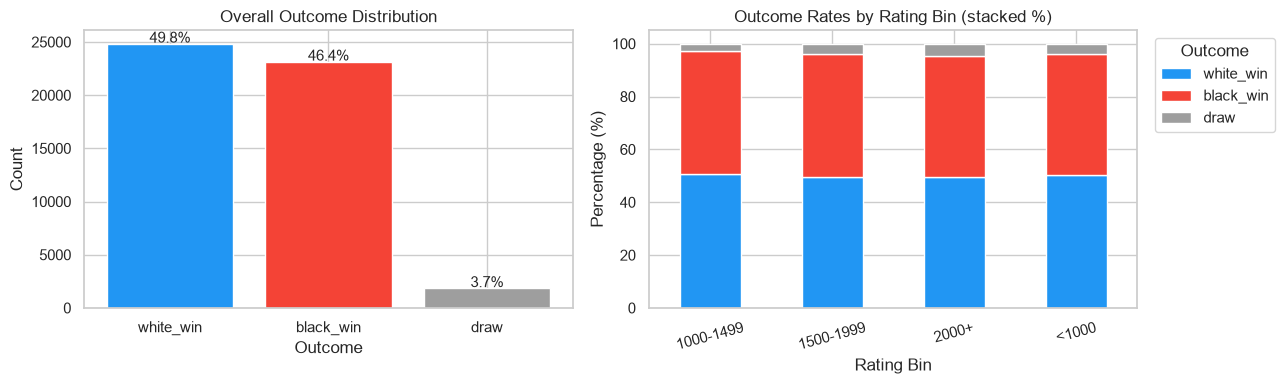

In [21]:
outcome_colors = {'white_win': '#2196F3', 'black_win': '#F44336', 'draw': '#9E9E9E'}
ordered_outcomes = ['white_win', 'black_win', 'draw']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Overall outcome bar ────────────────────────────────────────────────────
vc = df_feat['result_label'].value_counts().reindex(ordered_outcomes)
bars = axes[0].bar(
    vc.index,
    vc.values,
    color=[outcome_colors[o] for o in vc.index]
)
for bar, count in zip(bars, vc.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + len(df_feat) * 0.002,
        f'{count / len(df_feat) * 100:.1f}%',
        ha='center', fontsize=11
    )
axes[0].set_title('Overall Outcome Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Outcome')

# ── Outcome by rating bin (stacked %) ─────────────────────────────────────
ct = pd.crosstab(df_feat['rating_bin'], df_feat['result_label'], normalize='index') * 100
ct = ct.reindex(columns=ordered_outcomes)
ct.plot(kind='bar', stacked=True, ax=axes[1],
        color=[outcome_colors[o] for o in ordered_outcomes])
axes[1].set_title('Outcome Rates by Rating Bin (stacked %)')
axes[1].set_xlabel('Rating Bin')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 4.4 Chi-Squared Test: Rating Bin × Outcome

A chi-squared test on the contingency table of rating bin vs. outcome tests whether outcome distributions differ significantly across rating levels. A low p-value (conventionally < 0.05) suggests that rating level and outcome distribution are not independent.

In [22]:
ct_raw = pd.crosstab(df_feat['rating_bin'], df_feat['result_label'])
chi2, p, dof, expected = chi2_contingency(ct_raw)

print('Chi-squared test: Rating Bin x Outcome')
print(f'  chi2 = {chi2:.2f}   df = {dof}   p = {p:.4e}')
print()
print('Row-normalized contingency table (% within each rating bin):')
ct_pct = pd.crosstab(df_feat['rating_bin'], df_feat['result_label'], normalize='index') * 100
print(ct_pct.reindex(columns=ordered_outcomes).round(1).to_string())

Chi-squared test: Rating Bin x Outcome
  chi2 = 51.17   df = 6   p = 2.7441e-09

Row-normalized contingency table (% within each rating bin):
result_label  white_win  black_win  draw
rating_bin                              
1000-1499          50.7       46.4   2.9
1500-1999          49.4       46.8   3.8
2000+              49.5       45.9   4.6
<1000              50.2       45.9   3.9


### 4.5 Time Control Analysis

Faster time controls (bullet) may favor White due to reduced thinking time, while slower controls (classical) tend to see more draws as both players have more opportunity to equalize.

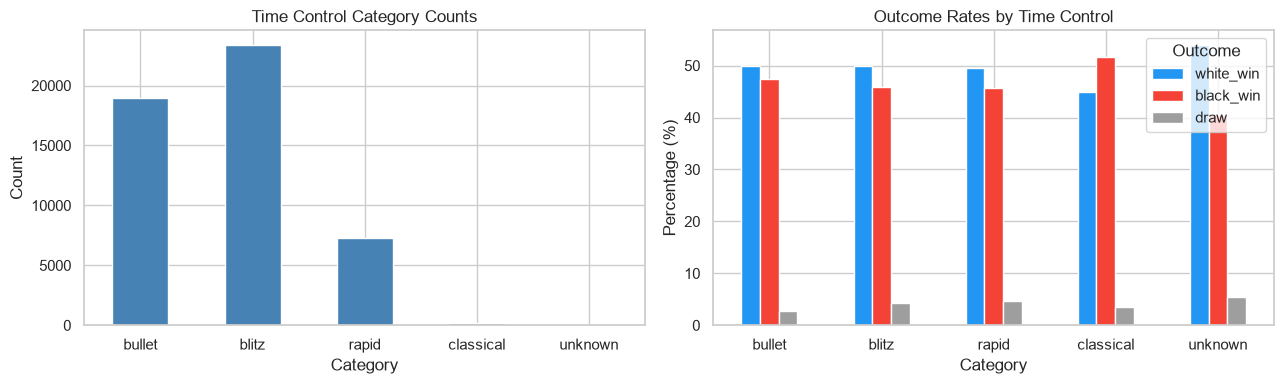

Chi-squared test: Time Control x Outcome
  chi2 = 96.95   df = 8   p = 1.7870e-17


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# TC distribution
tc_order = ['bullet', 'blitz', 'rapid', 'classical', 'other', 'unknown']
tc_vc = df_feat['tc_cat'].value_counts().reindex(tc_order).dropna()
tc_vc.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Time Control Category Counts')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Outcome by TC
ct_tc = pd.crosstab(df_feat['tc_cat'], df_feat['result_label'], normalize='index') * 100
ct_tc = ct_tc.reindex(index=tc_order, columns=ordered_outcomes).dropna(how='all')
ct_tc.plot(kind='bar', ax=axes[1],
           color=[outcome_colors[o] for o in ordered_outcomes])
axes[1].set_title('Outcome Rates by Time Control')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()

ct_tc_raw = pd.crosstab(df_feat['tc_cat'], df_feat['result_label'])
chi2_tc, p_tc, dof_tc, _ = chi2_contingency(ct_tc_raw)
print(f'Chi-squared test: Time Control x Outcome')
print(f'  chi2 = {chi2_tc:.2f}   df = {dof_tc}   p = {p_tc:.4e}')

### 4.6 Opening Move Analysis

White's first move (`ply_1`) and Black's response (`ply_2`) set the opening trajectory. The most common first moves (`e4`, `d4`, `Nf3`, `c4`) define broad opening families. We also test whether the first White move is associated with outcome using a chi-squared test.

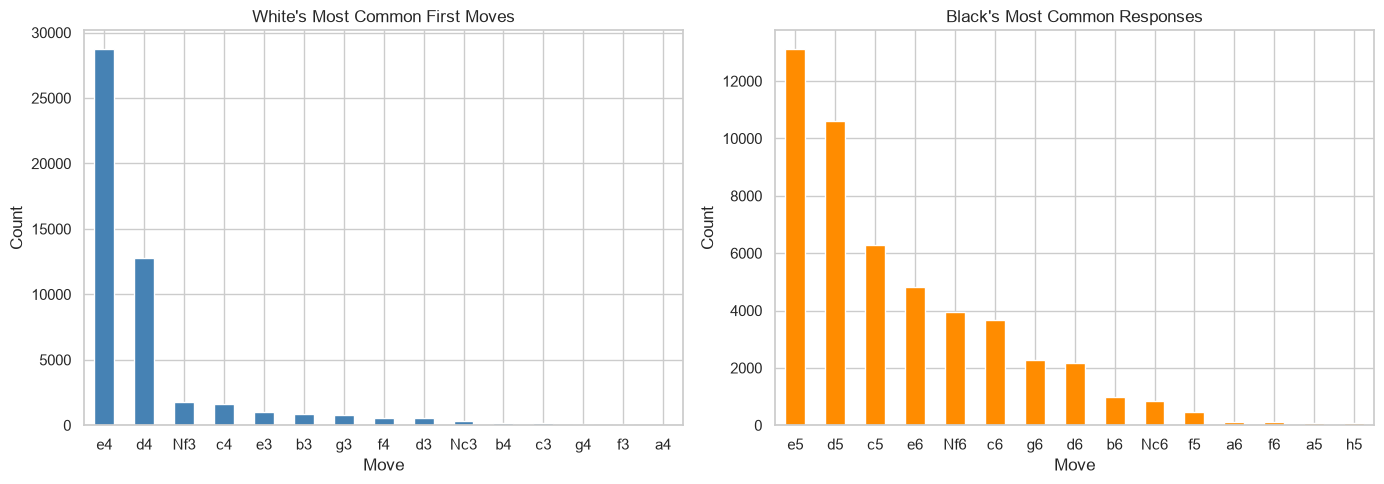

Outcome rates by White first move (top 10):
result_label  white_win  black_win  draw      n
ply_1                                          
Nc3                54.4       42.2   3.3    360
Nf3                50.9       44.2   4.9   1800
b3                 52.3       44.1   3.6    837
c4                 48.0       47.8   4.1   1647
d3                 47.8       47.6   4.5    529
d4                 50.1       46.3   3.7  12802
e3                 50.1       46.9   3.0   1045
e4                 49.8       46.5   3.7  28727
f4                 45.5       50.4   4.1    532
g3                 50.2       45.9   3.9    795

Chi-squared test: White First Move x Outcome
  chi2 = 24.56   df = 18   p = 1.3752e-01


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_w1 = df_feat['ply_1'].value_counts().head(15)
top_b1 = df_feat['ply_2'].value_counts().head(15)

top_w1.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("White's Most Common First Moves")
axes[0].set_xlabel('Move')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

top_b1.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title("Black's Most Common Responses")
axes[1].set_xlabel('Move')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Win rates for White's first move
print('Outcome rates by White first move (top 10):')
df_w1 = df_feat[df_feat['ply_1'].isin(top_w1.index[:10])]
w1_outcomes = pd.crosstab(df_w1['ply_1'], df_w1['result_label'], normalize='index') * 100
w1_outcomes = w1_outcomes.reindex(columns=ordered_outcomes)
w1_outcomes['n'] = df_w1.groupby('ply_1').size()
print(w1_outcomes.round(1).to_string())

ct_w1 = pd.crosstab(df_w1['ply_1'], df_w1['result_label'])
chi2_w1, p_w1, dof_w1, _ = chi2_contingency(ct_w1)
print(f'\nChi-squared test: White First Move x Outcome')
print(f'  chi2 = {chi2_w1:.2f}   df = {dof_w1}   p = {p_w1:.4e}')

### 4.7 Game Length Analysis

Game length (number of moves) varies substantially by outcome. Draws tend to be longer than decisive games, and games won by resignation may be shorter than games won by checkmate or time forfeit.

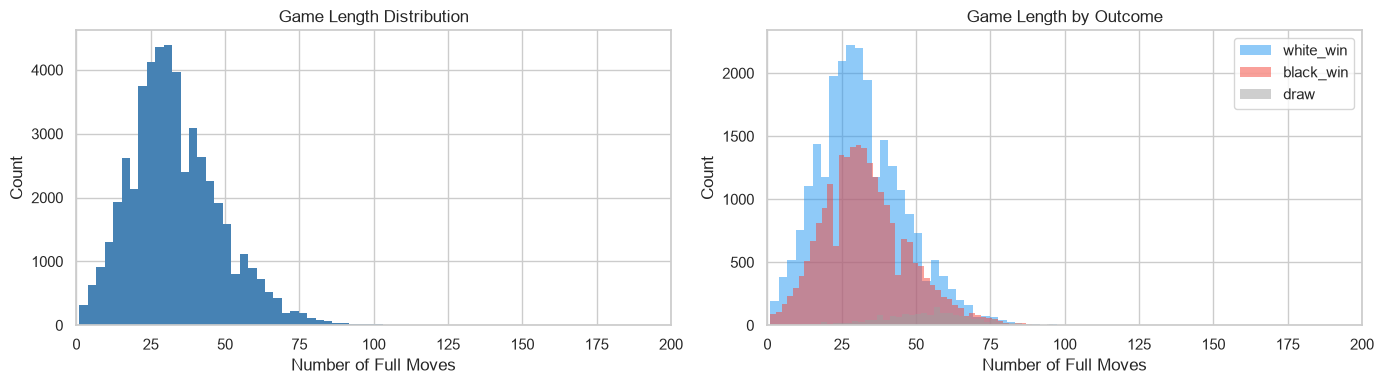

Game length summary statistics by outcome:
                  n  mean  median   std    Q1    Q3   IQR
result_label                                             
black_win     23147  33.2    32.0  14.5  23.0  42.0  19.0
draw           1852  54.4    55.0  19.1  43.0  65.0  22.0
white_win     24837  31.8    30.0  14.7  21.0  40.0  19.0


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_feat['num_moves'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Number of Full Moves')
axes[0].set_ylabel('Count')
axes[0].set_title('Game Length Distribution')
axes[0].set_xlim(0, 200)

for outcome in ordered_outcomes:
    subset = df_feat[df_feat['result_label'] == outcome]['num_moves']
    axes[1].hist(subset, bins=80, alpha=0.5,
                 label=outcome, color=outcome_colors[outcome], edgecolor='none')
axes[1].set_xlabel('Number of Full Moves')
axes[1].set_ylabel('Count')
axes[1].set_title('Game Length by Outcome')
axes[1].set_xlim(0, 200)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Game length summary statistics by outcome:')
gl_stats = df_feat.groupby('result_label')['num_moves'].agg(
    ['count', 'mean', 'median', 'std',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
)
gl_stats.columns = ['n', 'mean', 'median', 'std', 'Q1', 'Q3']
gl_stats['IQR'] = gl_stats['Q3'] - gl_stats['Q1']
print(gl_stats.round(1).to_string())

---
### Section 4 Recap

**What was done:** Ran descriptive statistics and three chi-squared tests -- rating bin x outcome, time control x outcome, and White's first move x outcome -- plus a breakdown of game length by outcome.

**Trends worth noting:**
- **Rating bin x outcome** is statistically significant (chi2=51.17, df=6, p=2.74e-9), but the practical effect is small: `white_win` rate barely moves across bins (50.7% down to ~49.4-49.5%), while the draw rate roughly climbs with rating (2.9% at `1000-1499` up to 4.6% at `2000+`) -- consistent with stronger players converting more games to draws instead of losses.
- **Time control x outcome** is also significant (chi2=96.95, df=8, p=1.79e-17), meaning outcome mix genuinely differs by time control (see the stacked bar chart above for the breakdown by category).
- **White's first move x outcome** is the one test that is *not* significant (chi2=24.56, df=18, p=0.14), despite an eye-catching spread in the raw numbers (`Nc3` 54.4% white-win over only 360 games vs. `f4` 45.5% over 532 games). The two most common openings, `e4` (28,727 games) and `d4` (12,802 games), sit almost exactly at the ~50% baseline -- it's the rarest first moves that look most extreme, which is exactly the pattern you'd expect from small-sample noise rather than a genuine opening advantage.
- **Game length by outcome:** decisive games average ~32 moves (`white_win` 31.8, `black_win` 33.2), while draws run far longer on average (54.4 moves, median 55) -- draws typically come from long, closely fought games rather than early resignations.

---
## Section 5: Frequent Patterns and Association Rules

### Methodology

**Goal:** Identify early-move sequences that commonly occur and determine whether they are associated with particular outcomes.

**Framework:** We use the **Apriori algorithm** via `mlxtend`.
- Each game is a **transaction** whose **items** are position-labeled half-moves (e.g., `w1:e4`, `b1:e5`, `w2:Nf3`) plus a result item (e.g., `result:white_win`).
- Apriori finds all **frequent itemsets** — combinations that appear in at least `min_support` fraction of games.
- From those, we generate **association rules** of the form `{antecedent} → {consequent}` and filter for rules whose consequent is a result item.

**Key metrics:**
| Metric | Definition |
|---|---|
| **Support** | P(antecedent ∪ consequent) — how common is this combination? |
| **Confidence** | P(consequent \| antecedent) — how often does the outcome follow given the moves? |
| **Lift** | Confidence / P(consequent) — how much more likely than baseline? Lift > 1 is a positive association. |

> **Scaling note:** For the full dataset, increase `MIN_SUPPORT` to reduce the transaction matrix to a manageable size. A threshold of 0.01 on 5M games still finds patterns present in 50 000+ games.

In [26]:
ply_cols = [f'ply_{i + 1}' for i in range(K_MOVES)]

def build_transactions(df, ply_cols, include_result=True):
    """Convert each game row into a list of position-labeled move items."""
    transactions = []
    for _, row in df.iterrows():
        items = []
        for i, col in enumerate(ply_cols, start=1):
            mv = row[col]
            if pd.notna(mv) and mv:
                side = 'w' if i % 2 == 1 else 'b'
                move_num = (i + 1) // 2
                items.append(f'{side}{move_num}:{mv}')
        if include_result and pd.notna(row.get('result_label')):
            items.append(f'result:{row["result_label"]}')
        transactions.append(items)
    return transactions

transactions = build_transactions(df_feat, ply_cols, include_result=True)

print(f'Transactions built: {len(transactions):,}')
print(f'Sample: {transactions[0]}')

Transactions built: 49,836
Sample: ['w1:e4', 'b1:c6', 'w2:d4', 'b2:d5', 'w3:e5', 'b3:Bf5', 'result:white_win']


In [27]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix: {df_te.shape[0]:,} rows x {df_te.shape[1]} unique items')
print(f'Unique items (first 15): {list(te.columns_[:15])}')

Transaction matrix: 49,836 rows x 716 unique items
Unique items (first 15): ['b1:Na6', 'b1:Nc6', 'b1:Nf6', 'b1:Nh6', 'b1:a5', 'b1:a6', 'b1:b5', 'b1:b6', 'b1:c5', 'b1:c6', 'b1:d5', 'b1:d6', 'b1:e5', 'b1:e6', 'b1:f5']


In [28]:
MIN_SUPPORT = 0.02   # 2% minimum — adjust higher for very large datasets

freq_items = apriori(
    df_te,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=5          # max itemset length: 4 moves + 1 result
)
freq_items = freq_items.sort_values('support', ascending=False)

print(f'Frequent itemsets found (min_support={MIN_SUPPORT}): {len(freq_items):,}')
print('\nTop 15 by support:')
freq_items.head(15)

Frequent itemsets found (min_support=0.02): 495

Top 15 by support:


,support,itemsets
41,0.576431,frozenset({w1:e4})
36,0.498375,frozenset({result:white_win})
34,0.464463,frozenset({result:black_win})
45,0.300746,frozenset({w2:Nf3})
214,0.287001,"frozenset({w1:e4, result:white_win})"
200,0.268220,"frozenset({result:black_win, w1:e4})"
5,0.263043,frozenset({b1:e5})
39,0.256883,frozenset({w1:d4})
238,0.241091,"frozenset({w2:Nf3, w1:e4})"
3,0.212537,frozenset({b1:d5})


In [29]:
rules = association_rules(freq_items, metric='lift', min_threshold=1.0)

rules['ant_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['con_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Total rules generated: {len(rules):,}')

# Filter: consequent must be a result item
result_items_set = {'result:white_win', 'result:black_win', 'result:draw'}
rules_outcome = rules[
    rules['consequents'].apply(lambda x: bool(x & result_items_set))
].copy()

print(f'Rules predicting an outcome: {len(rules_outcome):,}')

cols_display = ['ant_str', 'con_str', 'support', 'confidence', 'lift']
rules_outcome.sort_values('lift', ascending=False)[cols_display].head(20)

Total rules generated: 2,152
Rules predicting an outcome: 455


,ant_str,con_str,support,confidence,lift
1769,w2:exd5,"b1:d5, result:white_win, w1:e4",0.021310,0.479675,15.015749
1717,"b1:d5, w1:e4","result:black_win, w2:exd5",0.021470,0.320647,14.934372
1766,"b1:d5, w1:e4","result:white_win, w2:exd5",0.021310,0.318250,14.934372
1718,w2:exd5,"b1:d5, result:black_win, w1:e4",0.021470,0.483288,14.858204
1981,w3:exd5,"b2:d5, result:black_win, w1:e4",0.020648,0.469649,10.562006
1973,"b2:d5, w1:e4","result:black_win, w3:exd5",0.020648,0.219778,10.094793
2075,w2:c4,"result:white_win, w1:d4, w3:Nc3",0.020287,0.233811,8.774261
2073,"w1:d4, w3:Nc3","result:white_win, w2:c4",0.020287,0.383827,8.770471
1543,b1:c6,"b2:d5, result:black_win, w1:e4",0.022474,0.305760,6.876295
1977,"w1:e4, w3:exd5","b2:d5, result:black_win",0.020648,0.488140,6.835337


In [30]:
print('Top 12 outcome-predicting rules by lift')
print('=' * 75)
for _, row in rules_outcome.sort_values('lift', ascending=False).head(12).iterrows():
    print(f'  IF   {row["ant_str"]}')
    print(f'  THEN {row["con_str"]}')
    print(f'       support={row["support"]:.3f}  confidence={row["confidence"]:.3f}  lift={row["lift"]:.3f}')
    print()

Top 12 outcome-predicting rules by lift
  IF   w2:exd5
  THEN b1:d5, result:white_win, w1:e4
       support=0.021  confidence=0.480  lift=15.016

  IF   b1:d5, w1:e4
  THEN result:black_win, w2:exd5
       support=0.021  confidence=0.321  lift=14.934

  IF   b1:d5, w1:e4
  THEN result:white_win, w2:exd5
       support=0.021  confidence=0.318  lift=14.934

  IF   w2:exd5
  THEN b1:d5, result:black_win, w1:e4
       support=0.021  confidence=0.483  lift=14.858

  IF   w3:exd5
  THEN b2:d5, result:black_win, w1:e4
       support=0.021  confidence=0.470  lift=10.562

  IF   b2:d5, w1:e4
  THEN result:black_win, w3:exd5
       support=0.021  confidence=0.220  lift=10.095

  IF   w2:c4
  THEN result:white_win, w1:d4, w3:Nc3
       support=0.020  confidence=0.234  lift=8.774

  IF   w1:d4, w3:Nc3
  THEN result:white_win, w2:c4
       support=0.020  confidence=0.384  lift=8.770

  IF   b1:c6
  THEN b2:d5, result:black_win, w1:e4
       support=0.022  confidence=0.306  lift=6.876

  IF   w1:e4,

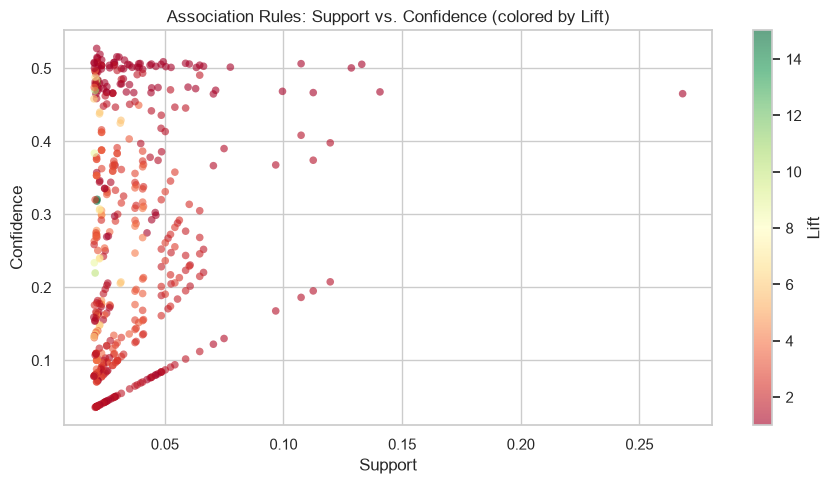

In [31]:
# Support vs. confidence scatter, colored by lift
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    rules_outcome['support'],
    rules_outcome['confidence'],
    c=rules_outcome['lift'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='none',
    s=30
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules: Support vs. Confidence (colored by Lift)')
plt.tight_layout()
plt.show()

---
### Beyond the Opening: Move Sequences Anywhere in the Game

The analysis above only finds patterns among moves in the first `K_MOVES` plies (the opening). This section asks a related but different question: does a short *sequence* of moves -- for example white_move, black_move, white_move, black_move -- show up anywhere in the game (not just at the very start) in a way that's associated with a White win?

**Approach: sliding windows, not position-free sets**
- Positions are still preserved *within* each window (`w1` is always that window's first White move, `b1` its first Black reply, `w2`/`b2` the second pair, and so on) -- we're just no longer pinning a window to one fixed ply number like `w15`. The same 2-full-move pattern is now recognized whether it happens on moves 3-4 of one game or moves 12-13 of another.
- Each game (already re-parsed to `MAX_PLIES_DEEP` plies below) is sliced into non-overlapping `WINDOW_PLIES`-ply windows (default 4 plies = white, black, white, black). Every window becomes its own transaction, tagged with that game's result.
- Because one game now contributes several windows, and a move from anywhere in the game can land in any window slot, both the transaction count and the item vocabulary are much larger than the opening-only analysis.

> **On the earlier memory error:** the previous version of this section built one *position-free* item set per game across 40 plies with `min_support=0.01`. That combination is what blew up memory -- pooling that many possible moves into a handful of unordered items, at a low support threshold, makes Apriori's itemset search explode combinatorially. This version fixes it four ways: (1) window-relative positions keep items meaningful instead of an unordered bag, (2) non-overlapping windows bound the number of transactions, (3) `MIN_SUPPORT_DEEP` is raised rather than lowered, and (4) transactions are encoded as a **sparse** matrix with Apriori run in `low_memory` mode, so the full dense boolean matrix and candidate itemsets are never materialized all at once.

In [32]:
MAX_PLIES_DEEP = 40   # ~20 full moves per side -- opening through early middlegame

df_deep_raw = parse_pgn(RAW_PGN, n_games=n_to_parse, k_moves=MAX_PLIES_DEEP)

# Restrict to the same games that survived cleaning in Section 2, and attach their outcome
deep_ply_cols = [f'ply_{i + 1}' for i in range(MAX_PLIES_DEEP)]
df_deep = df_deep_raw.merge(df_feat[['game_id', 'result_label']], on='game_id', how='inner')

print(f'Deep-parsed games retained: {len(df_deep):,}')

      10,000  |  33s  |  306 games/s
      20,000  |  63s  |  316 games/s
      30,000  |  95s  |  316 games/s
      40,000  |  126s  |  318 games/s
      50,000  |  158s  |  317 games/s
Done: 50,000 games in 157.9s  (317 games/s)
Deep-parsed games retained: 49,836


In [33]:
WINDOW_PLIES = 4   # length of each move-sequence window: white, black, white, black
WINDOW_STEP  = 4   # non-overlapping windows by default; lower it (e.g. 2) for overlapping windows -- more coverage, more memory

def build_window_transactions(df, ply_cols, window_plies=4, step=4, include_result=True):
    """
    Slide a window of `window_plies` plies across each game's move list (in
    steps of `step`), turning every window into its own transaction. Items
    are labeled by their position *within the window* (w1, b1, w2, b2, ...)
    rather than their absolute ply number, so the same short sequence is
    recognized no matter where in the game it occurs.
    """
    transactions = []
    for _, row in df.iterrows():
        moves = [row[col] for col in ply_cols]
        for start in range(0, len(moves) - window_plies + 1, step):
            window = moves[start:start + window_plies]
            if any(pd.isna(mv) or not mv for mv in window):
                break  # game ended before this window completes -- later windows will too
            items = []
            for i, mv in enumerate(window):
                side = 'w' if (start + i) % 2 == 0 else 'b'
                move_num = i // 2 + 1
                items.append(f'{side}{move_num}:{mv}')
            if include_result and pd.notna(row.get('result_label')):
                items.append(f'result:{row["result_label"]}')
            transactions.append(items)
    return transactions

window_transactions = build_window_transactions(
    df_deep, deep_ply_cols, window_plies=WINDOW_PLIES, step=WINDOW_STEP, include_result=True
)

print(f'Games: {len(df_deep):,}')
print(f'Windows (transactions) built: {len(window_transactions):,}')
print(f'Sample: {window_transactions[0]}')

Games: 49,836
Windows (transactions) built: 467,227
Sample: ['w1:e4', 'b1:c6', 'w2:d4', 'b2:d5', 'result:white_win']


In [34]:
te_deep = TransactionEncoder()
te_deep_sparse = te_deep.fit(window_transactions).transform(window_transactions, sparse=True)
df_te_deep = pd.DataFrame.sparse.from_spmatrix(te_deep_sparse, columns=te_deep.columns_)

print(f'Transaction matrix: {df_te_deep.shape[0]:,} rows x {df_te_deep.shape[1]} unique items (sparse)')
print(f'Unique items (first 15): {list(te_deep.columns_[:15])}')

Transaction matrix: 467,227 rows x 6433 unique items (sparse)
Unique items (first 15): ['b1:Ba1', 'b1:Ba2', 'b1:Ba2+', 'b1:Ba3', 'b1:Ba3+', 'b1:Ba4', 'b1:Ba4+', 'b1:Ba5', 'b1:Ba5+', 'b1:Ba6', 'b1:Ba6+', 'b1:Ba7', 'b1:Ba8', 'b1:Bb1', 'b1:Bb1+']


In [35]:
# Raised from the opening analysis's MIN_SUPPORT rather than lowered: window-relative
# items pool moves from anywhere in the game, so the vocabulary is much wider than the
# opening-only analysis, and Apriori needs a higher threshold (plus low_memory) to stay tractable.
MIN_SUPPORT_DEEP = 0.02

freq_items_deep = apriori(
    df_te_deep,
    min_support=MIN_SUPPORT_DEEP,
    use_colnames=True,
    max_len=WINDOW_PLIES + 1,   # window moves + 1 result item
    low_memory=True
)
freq_items_deep = freq_items_deep.sort_values('support', ascending=False)

print(f'Frequent itemsets found (min_support={MIN_SUPPORT_DEEP}): {len(freq_items_deep):,}')
print('\nTop 15 by support:')
freq_items_deep.head(15)

Frequent itemsets found (min_support=0.02): 41

Top 15 by support:


,support,itemsets
17,0.493154,frozenset({result:white_win})
15,0.467833,frozenset({result:black_win})
22,0.070741,frozenset({w1:e4})
24,0.059956,frozenset({w2:Nf3})
21,0.050205,frozenset({w1:d4})
10,0.044734,frozenset({b2:Nf6})
1,0.044509,frozenset({b1:Nf6})
9,0.043953,frozenset({b2:Nc6})
7,0.040032,frozenset({b1:e5})
16,0.039013,frozenset({result:draw})


In [36]:
rules_deep = association_rules(freq_items_deep, metric='lift', min_threshold=1.0)

rules_deep['ant_str'] = rules_deep['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_deep['con_str'] = rules_deep['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Total rules generated: {len(rules_deep):,}')

# Filter: consequent must be a result item (reuses result_items_set from above)
rules_deep_outcome = rules_deep[
    rules_deep['consequents'].apply(lambda x: bool(x & result_items_set))
].copy()

print(f'Rules predicting an outcome: {len(rules_deep_outcome):,}')

rules_deep_outcome.sort_values('lift', ascending=False)[cols_display].head(20)

Total rules generated: 18
Rules predicting an outcome: 7


,ant_str,con_str,support,confidence,lift
9,w1:d4,result:white_win,0.025097,0.499893,1.013665
0,w1:e4,result:white_win,0.035158,0.497005,1.007808
16,b2:Nc6,result:white_win,0.021827,0.496591,1.006970
12,b2:Nf6,result:white_win,0.022178,0.495766,1.005295
2,w2:Nf3,result:white_win,0.029664,0.494770,1.003277
14,b1:Nf6,result:white_win,0.021987,0.493989,1.001693
4,w2:Nf3,result:black_win,0.028055,0.467926,1.000199


In [37]:
# Rules specifically predicting a White win, ranked by lift
rules_white_win_deep = rules_deep_outcome[
    rules_deep_outcome['consequents'] == frozenset({'result:white_win'})
].sort_values('lift', ascending=False)

print('Top 12 move combinations (anywhere in the first MAX_PLIES_DEEP plies) associated with a White win')
print('=' * 90)
for _, row in rules_white_win_deep.head(12).iterrows():
    print(f'  IF   {row["ant_str"]}')
    print(f'  THEN {row["con_str"]}')
    print(f'       support={row["support"]:.3f}  confidence={row["confidence"]:.3f}  lift={row["lift"]:.3f}')
    print()

Top 12 move combinations (anywhere in the first MAX_PLIES_DEEP plies) associated with a White win
  IF   w1:d4
  THEN result:white_win
       support=0.025  confidence=0.500  lift=1.014

  IF   w1:e4
  THEN result:white_win
       support=0.035  confidence=0.497  lift=1.008

  IF   b2:Nc6
  THEN result:white_win
       support=0.022  confidence=0.497  lift=1.007

  IF   b2:Nf6
  THEN result:white_win
       support=0.022  confidence=0.496  lift=1.005

  IF   w2:Nf3
  THEN result:white_win
       support=0.030  confidence=0.495  lift=1.003

  IF   b1:Nf6
  THEN result:white_win
       support=0.022  confidence=0.494  lift=1.002



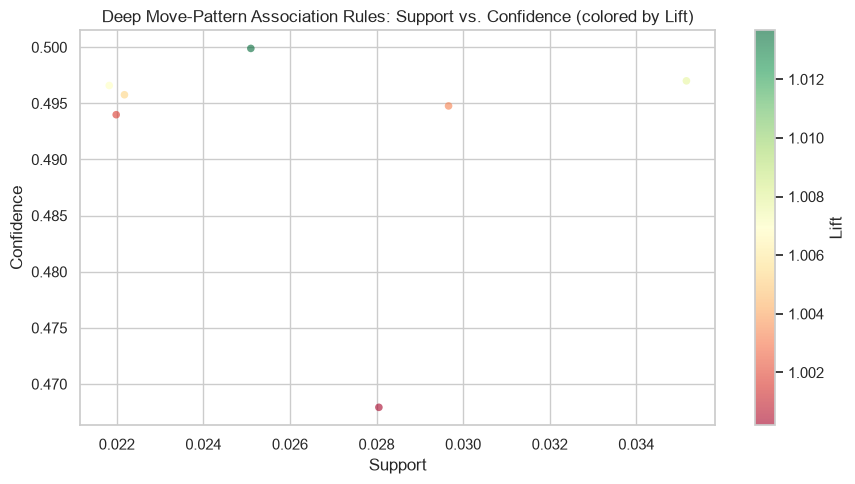

In [38]:
# Support vs. confidence scatter, colored by lift
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    rules_deep_outcome['support'],
    rules_deep_outcome['confidence'],
    c=rules_deep_outcome['lift'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='none',
    s=30
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Deep Move-Pattern Association Rules: Support vs. Confidence (colored by Lift)')
plt.tight_layout()
plt.show()

---
### Section 5 Recap

**What was done:** Built market-basket-style transactions from each game's first `K_MOVES` position-labeled opening moves plus a result item, ran Apriori (`min_support=0.02`), and filtered the resulting association rules down to those predicting an outcome. A follow-up subsection then re-parsed the same games to `MAX_PLIES_DEEP` plies and mined sliding 4-ply windows (see below) for the same kind of outcome-predicting patterns, but without pinning them to a fixed opening position.

**Trends worth noting:**
- Apriori found 495 frequent itemsets in the opening-only analysis, generating 2,152 total rules, of which 455 predict an outcome.
- The single highest-lift rule (lift=15.02) is `w2:exd5 -> b1:d5, result:white_win, w1:e4` -- but the near-identical rule for `result:black_win` on the same antecedent has almost the same lift (14.86). That's an important caveat: a lot of the top-lift rules here mostly capture 'these moves belong to the same well-known opening line' (in this case, the Caro-Kann Advance) rather than 'this move predicts who wins.'
- **Beyond the Opening results:** slicing 49,836 games into 467,227 non-overlapping 4-ply windows produced a much wider item vocabulary (6,433 unique window-relative items vs. 716 in the opening-only analysis) but far fewer frequent itemsets at the same `min_support=0.02` -- only 41, yielding just 7 outcome-predicting rules (6 of them for `result:white_win`).
- More importantly, those 6 rules all have lift barely above 1.0 (1.00-1.01) -- essentially no association, not far from a coin flip. And every one of them is a *single* move (`w1:d4`, `w1:e4`, `w2:Nf3`, `b1:Nf6`, `b2:Nc6`, `b2:Nf6`), all from the first window -- which covers the same plies as the opening-only analysis above. In other words, this run didn't surface genuine multi-move sequences from later in the game; it mostly just re-found the (weak) opening signal already visible above, because a 4-move combination has to recur identically across enough of 467,227 windows to clear 2% support, and that's a much higher bar for windows drawn from anywhere in the game than for windows pinned to the actual opening.
- If finding real mid-game sequences matters more than avoiding another memory error, the next thing to try is lowering `MIN_SUPPORT_DEEP` (now safe to do since the sparse encoding and `low_memory=True` are what prevented the earlier crash, not the support threshold) and/or reducing `WINDOW_STEP` for overlapping windows, which gives the same sequence more chances to be counted.

---
## Section 6: Supervised Classification

### Overview

We test whether game metadata and engineered features can predict game outcomes. Two prediction targets are used:

| Target | Type | Description |
|---|---|---|
| `white_wins` | Binary | 1 = White wins; 0 = Black wins or draw |
| `result_label` | 3-class | `white_win`, `black_win`, `draw` |

**Features used:**
- Numeric: `rating_diff`, `avg_rating`, `num_plies`
- Categorical (one-hot encoded): `tc_cat`, `eco_family`, `ply_1` (White's first move)

**Models:**
1. Majority-class baseline
2. Higher-rated-player-wins heuristic
3. Logistic Regression
4. Decision Tree
5. Random Forest

**Evaluation:** Accuracy, Precision, Recall, F1 (weighted for multiclass), Confusion Matrix, ROC-AUC (binary).

> Because accuracy alone is misleading when classes are imbalanced, we prioritize F1 and ROC-AUC.

In [39]:
NUM_FEATURES = ['rating_diff', 'avg_rating', 'num_plies']
CAT_FEATURES = ['tc_cat', 'eco_family', 'ply_1']
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

TARGET_BIN   = 'white_wins'      # binary
TARGET_MULTI = 'result_label'    # 3-class

df_ml = df_feat[ALL_FEATURES + [TARGET_BIN, TARGET_MULTI]].copy()

# Fill missing categoricals with a placeholder
df_ml[CAT_FEATURES] = df_ml[CAT_FEATURES].fillna('missing')

# Drop remaining NaN rows (should be minimal)
df_ml = df_ml.dropna()

print(f'ML-ready rows: {len(df_ml):,}')
print(f'\nBinary target distribution:')
print(df_ml[TARGET_BIN].value_counts())
print(f'\nMulticlass target distribution:')
print(df_ml[TARGET_MULTI].value_counts())

ML-ready rows: 49,836

Binary target distribution:
white_wins
0    24999
1    24837
Name: count, dtype: int64

Multiclass target distribution:
result_label
white_win    24837
black_win    23147
draw          1852
Name: count, dtype: int64


In [40]:
X = df_ml[ALL_FEATURES]
y_bin   = df_ml[TARGET_BIN].astype(int)
y_multi = df_ml[TARGET_MULTI]

# Stratify on multiclass target to preserve class proportions in both splits
X_train, X_test, yb_train, yb_test, ym_train, ym_test = train_test_split(
    X, y_bin, y_multi,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_multi
)

print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')
print(f'\nTest class distribution:')
print(ym_test.value_counts())

Train: 39,868   Test: 9,968

Test class distribution:
result_label
white_win    4968
black_win    4630
draw          370
Name: count, dtype: int64


In [41]:
# Build the ColumnTransformer once; fit on train, apply to both splits
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

n_features_out = X_train_proc.shape[1]
print(f'Encoded feature matrix: train {X_train_proc.shape}  test {X_test_proc.shape}')

Encoded feature matrix: train (39868, 33)  test (9968, 33)


In [42]:
def evaluate_binary(name, y_true, y_pred, y_prob_pos=None):
    """Return a dict of binary classification metrics."""
    auc_val = roc_auc_score(y_true, y_prob_pos) if y_prob_pos is not None else np.nan
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   auc_val,
    }

all_results = []

In [43]:
# ── Baseline 1: Majority class ─────────────────────────────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train_proc, yb_train)
yb_pred_dummy = dummy.predict(X_test_proc)
yb_prob_dummy = dummy.predict_proba(X_test_proc)[:, 1]
all_results.append(evaluate_binary('Majority Class', yb_test, yb_pred_dummy, yb_prob_dummy))

# ── Baseline 2: Higher-rated player wins ──────────────────────────────────
# rating_diff is the first numeric feature; predict White wins when diff > 0
rating_diff_test = X_test['rating_diff'].values
yb_pred_hr = (rating_diff_test > 0).astype(int)
all_results.append(evaluate_binary('Higher-Rated Wins', yb_test, yb_pred_hr))

pd.DataFrame(all_results).set_index('Model').round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Majority Class,0.502,0.000,0.000,0.000,0.5
Higher-Rated Wins,0.557,0.556,0.552,0.554,NaN


In [44]:
# ── Logistic Regression ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
lr.fit(X_train_proc, yb_train)
yb_pred_lr = lr.predict(X_test_proc)
yb_prob_lr = lr.predict_proba(X_test_proc)[:, 1]
all_results.append(evaluate_binary('Logistic Regression', yb_test, yb_pred_lr, yb_prob_lr))

print('Logistic Regression fitted.')
print(f'  Converged: {lr.n_iter_[0]} iterations')

Logistic Regression fitted.
  Converged: 27 iterations


In [45]:
# ── Decision Tree ─────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=RANDOM_SEED)
dt.fit(X_train_proc, yb_train)
yb_pred_dt = dt.predict(X_test_proc)
yb_prob_dt = dt.predict_proba(X_test_proc)[:, 1]
all_results.append(evaluate_binary('Decision Tree', yb_test, yb_pred_dt, yb_prob_dt))

print(f'Decision Tree fitted.  Depth: {dt.get_depth()}  Leaves: {dt.get_n_leaves()}')

Decision Tree fitted.  Depth: 8  Leaves: 89


In [46]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=30,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_train_proc, yb_train)
yb_pred_rf = rf.predict(X_test_proc)
yb_prob_rf = rf.predict_proba(X_test_proc)[:, 1]
all_results.append(evaluate_binary('Random Forest', yb_test, yb_pred_rf, yb_prob_rf))

print('Random Forest fitted.')

Random Forest fitted.


Binary classification results (target: white_wins):
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Majority Class         0.5016     0.0000  0.0000  0.0000   0.5000
Higher-Rated Wins      0.5571     0.5561  0.5519  0.5540      NaN
Logistic Regression    0.5598     0.5573  0.5680  0.5626   0.6008
Decision Tree          0.5930     0.5793  0.6697  0.6212   0.6551
Random Forest          0.6295     0.6276  0.6310  0.6293   0.6698


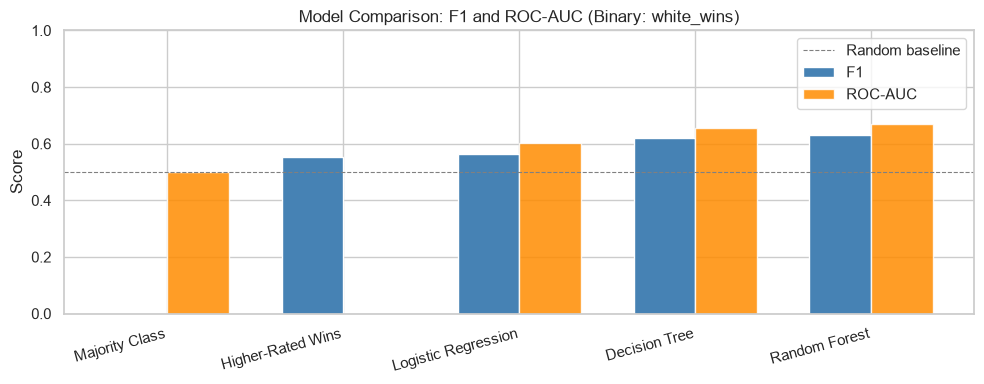

In [47]:
results_df = pd.DataFrame(all_results).set_index('Model')
print('Binary classification results (target: white_wins):')
print(results_df.round(4).to_string())

# Bar chart comparing F1 and ROC-AUC
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['F1'],      width, label='F1',      color='steelblue')
ax.bar(x + width/2, results_df['ROC-AUC'], width, label='ROC-AUC', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: F1 and ROC-AUC (Binary: white_wins)')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.show()

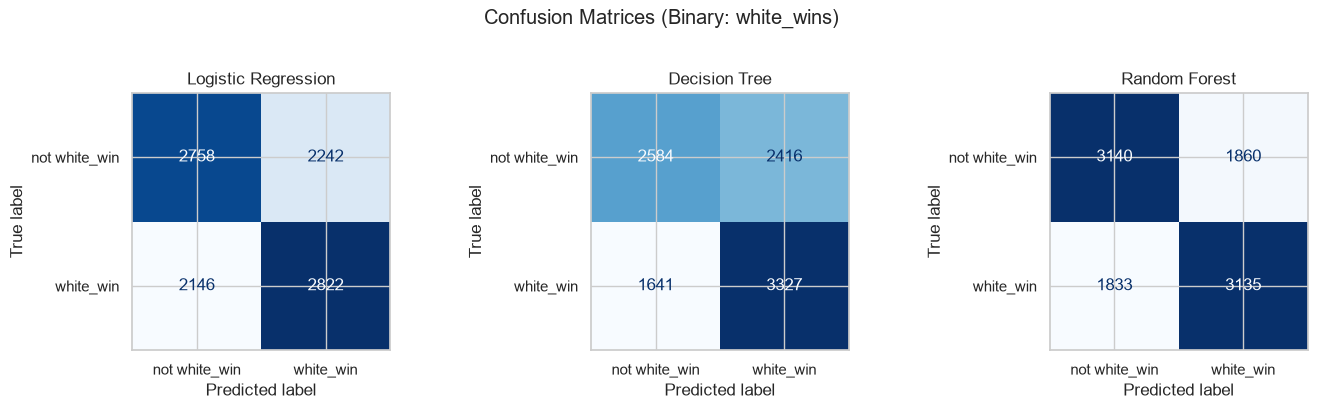

In [48]:
# Confusion matrices for the three learned models
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
model_preds = [yb_pred_lr, yb_pred_dt, yb_pred_rf]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, pred in zip(axes, model_names, model_preds):
    cm = confusion_matrix(yb_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['not white_win', 'white_win'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices (Binary: white_wins)', y=1.02)
plt.tight_layout()
plt.show()

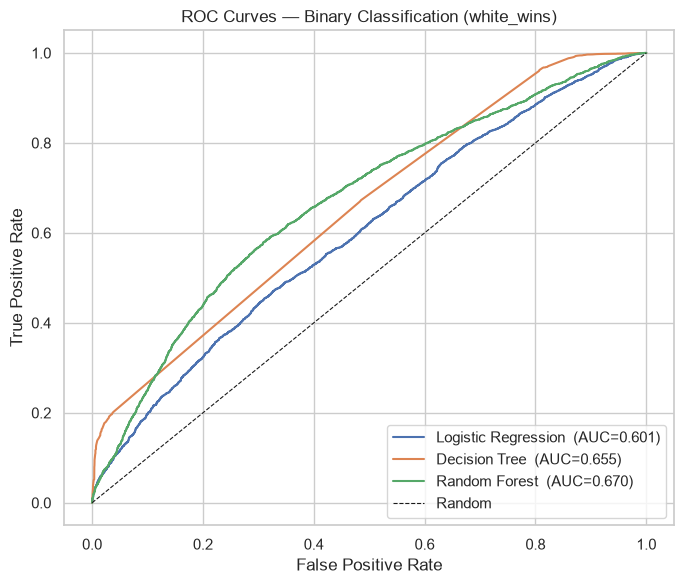

In [49]:
# ROC curves for probabilistic models
roc_models = [
    ('Logistic Regression', yb_prob_lr),
    ('Decision Tree',       yb_prob_dt),
    ('Random Forest',       yb_prob_rf),
]

fig, ax = plt.subplots(figsize=(7, 6))
for name, probs in roc_models:
    fpr, tpr, _ = roc_curve(yb_test, probs)
    auc_val = roc_auc_score(yb_test, probs)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Binary Classification (white_wins)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

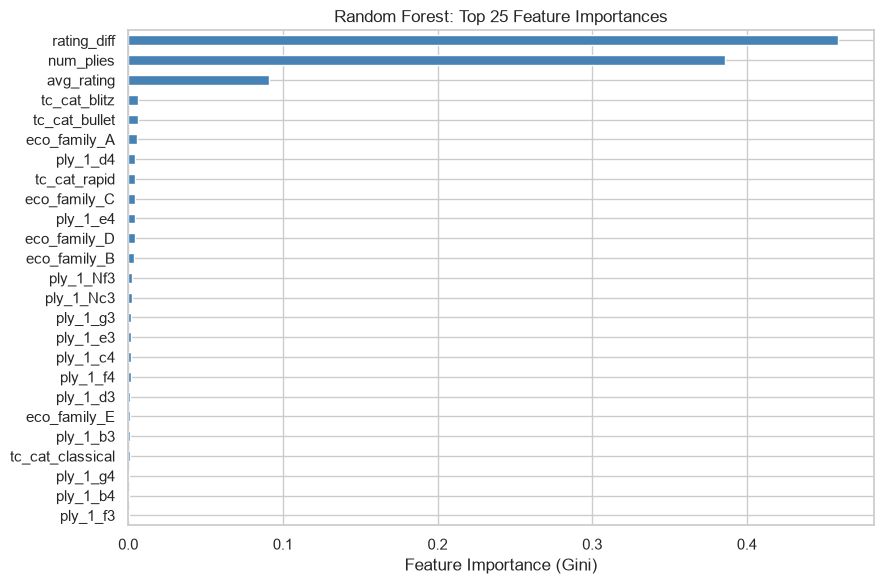

Top 10 features:
rating_diff      0.4592
num_plies        0.3858
avg_rating       0.0908
tc_cat_blitz     0.0065
tc_cat_bullet    0.0063
eco_family_A     0.0054
ply_1_d4         0.0047
tc_cat_rapid     0.0046
eco_family_C     0.0044
ply_1_e4         0.0042


In [50]:
# Feature importances from Random Forest
cat_feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(CAT_FEATURES)
    .tolist()
)
feature_names = NUM_FEATURES + cat_feature_names

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 25
top_n = min(25, len(feat_imp))
fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.head(top_n).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Random Forest: Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

print(f'Top 10 features:')
print(feat_imp.head(10).round(4).to_string())

In [51]:
# ── Multiclass comparison: result_label (white_win / black_win / draw) ─────
print('=== Multiclass Classification: result_label ===')
print('(Weighted-average metrics across all three classes)')
print()

mc_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=RANDOM_SEED)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1)),
]

le = LabelEncoder()
ym_train_enc = le.fit_transform(ym_train)
ym_test_enc  = le.transform(ym_test)

mc_results = []
for name, clf in mc_models:
    clf.fit(X_train_proc, ym_train_enc)
    ym_pred = clf.predict(X_test_proc)
    mc_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(ym_test_enc, ym_pred),
        'Precision': precision_score(ym_test_enc, ym_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(ym_test_enc, ym_pred, average='weighted', zero_division=0),
        'F1':        f1_score(ym_test_enc, ym_pred, average='weighted', zero_division=0),
    })

mc_df = pd.DataFrame(mc_results).set_index('Model')
print(mc_df.round(4).to_string())

=== Multiclass Classification: result_label ===
(Weighted-average metrics across all three classes)

                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.5340     0.5249  0.5340  0.5178
Decision Tree          0.5561     0.5368  0.5561  0.5368
Random Forest          0.5588     0.5497  0.5588  0.5205


---
### Section 6 Recap

**What was done:** Built a feature set (`rating_diff`, `avg_rating`, `num_plies`, `tc_cat`, `eco_family`, `ply_1`) from the 49,836 cleaned games, split 80/20 into train (39,868) and test (9,968) sets stratified on outcome, and compared two baselines (majority class; 'higher-rated player wins') against logistic regression, a decision tree, and a random forest -- for both the binary `white_wins` target and the 3-class `result_label` target.

**Trends worth noting:**
- The majority-class baseline only reaches 50.16% accuracy (the classes are almost evenly split: 24,999 vs. 24,837), but the zero-training 'higher-rated player wins' heuristic already jumps to 55.71% -- confirming rating alone carries real signal before any model is fit.
- All three models beat both baselines, topping out with Random Forest at 62.95% accuracy / 0.629 F1 / 0.670 ROC-AUC. That is a genuine improvement over the baselines, but still far from strongly predictive -- a large share of who wins a chess game clearly isn't captured by these six features.
- Feature importance makes this concrete: `rating_diff` (0.459) and `num_plies` (0.386) alone account for ~85% of the Random Forest's total importance; `avg_rating` is a distant third (0.091), and every categorical feature (time control, ECO family, White's first move) individually contributes under 1%. In short, 'who's rated higher' and 'how long the game lasted' are doing almost all the work -- opening choice and time control add little incremental signal.
- The 3-class version of the problem is uniformly harder: Random Forest accuracy drops from 62.95% (binary) to 55.88% (multiclass), which tracks with `draw` being a rare (3.7%) and easy-to-miss third class.

---
## Section 7: Summary

### What This Pipeline Produces

| Artifact | Location |
|---|---|
| Raw parsed table | `data/interim/games_raw.parquet` |
| Cleaned table | `data/interim/games_cleaned.parquet` |
| Game-level features | `data/processed/games_featured.parquet` |
| Move-sequence table | `data/processed/move_sequences.parquet` |

### Analysis Coverage

| Component | Methods Used |
|---|---|
| Descriptive | Count, mean, median, SD, IQR, Q1/Q3; grouped outcome rates by rating bin, time control, opening, game length |
| Association rules | Apriori (min_support), support, confidence, lift; antecedents = move sequences, consequents = outcomes |
| Categorical comparisons | Chi-squared tests on rating bin × outcome, time control × outcome, opening × outcome |
| Classification | Logistic regression, decision tree, random forest vs. two baselines; accuracy, precision, recall, F1, confusion matrix, ROC-AUC |

### Scaling to the Full Dataset

Set `SAMPLE_MODE = False` in **Section 0** and re-run the notebook.

- **Parsing:** The stream parser reads the PGN one game at a time, so memory use is constant regardless of file size. Expect roughly 1–2 hours for ~5 million games at 10 000 games/s.
- **Association rules:** Increase `MIN_SUPPORT` (e.g., to `0.005`) to keep the transaction matrix within memory. Common opening patterns (e4, d4, c4 etc.) will still far exceed any reasonable threshold.
- **Classification:** `sklearn` models with `n_jobs=-1` scale efficiently. For very large datasets, consider reducing `n_estimators` or sampling stratified subsets for training.
- **Parquet files:** Both output tables will grow proportionally but remain efficiently column-compressed on disk.